In [5]:
import gc
# import torch

gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

import os
os.listdir(); os.chdir("/aiau010_scratch/azm0269/clover/")

from clover.utils.utils import notebook_line_magic
notebook_line_magic()

In [6]:
import json
from pathlib import Path
import pandas as pd
import numpy as np


baselines = ["md3po", "ddpo", "b2diffurl", "dpok"]
eval_path = Path("outputs/")
training_data_eval_file = "training_metrics.json"
evaluation_data_eval_file = "eval_metrics.json"

def get_training_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    all_metric_entries = []
    for entry in list_of_metrics:
        all_metric_entries.append(entry['metrics'])
    df = pd.DataFrame(all_metric_entries)
    return df

def get_eval_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    
    scores = ['bert_reward', 'clip_reward']
    eval_summary = list()
    for entry in list_of_metrics:
        for score in scores:
            eval_summary.append({
                "value": round(np.array(entry[score]).mean(), 4),
                "score": score,
                "epoch": entry['epoch']
            })
    eval_df = pd.DataFrame(eval_summary)
    return eval_df
    
def get_metrics():
    training_eval_df = pd.DataFrame()
    eval_df = pd.DataFrame()
    for baseline in baselines:
        baseline_path = eval_path / baseline
        training_data_eval_file_path = baseline_path / "training_evals" / training_data_eval_file
        eval_data_file_path = baseline_path / "evals" / evaluation_data_eval_file

        
        df = get_training_metrics_df(training_data_eval_file_path)
        df["method"] = baseline
        training_eval_df = pd.concat([training_eval_df, df], ignore_index=True)

        df = get_eval_metrics_df(eval_data_file_path)
        df["method"] = baseline
        eval_df = pd.concat([eval_df, df], ignore_index=True)
    return training_eval_df, eval_df

In [22]:
training_eval_df, eval_df = get_metrics()

File outputs/b2diffurl/training_evals/training_metrics.json does not exist. Skipping.
File outputs/b2diffurl/evals/eval_metrics.json does not exist. Skipping.
File outputs/dpok/training_evals/training_metrics.json does not exist. Skipping.
File outputs/dpok/evals/eval_metrics.json does not exist. Skipping.


In [23]:
import matplotlib.pyplot as plt

eval_summary = eval_df.pivot_table(
    index=['method', 'score'],
    columns='epoch',
    values='value',
)
# eval_summary.T.iloc[:, 0].plot()
# plt.title("Bert Reward")
# plt.show()
# eval_summary.T.iloc[:, 1].plot()
# plt.title("Clip Reward")
# plt.show()
eval_summary.T.round(3)

method        ddpo                   md3po            
score  bert_reward clip_reward bert_reward clip_reward
epoch                                                 
2.0          0.565       0.343       0.575       0.338

In [5]:
cols = ['advantage_mean', 'approx_kl', 'current_reward_mean', 'current_reward_std', 'epoch', 'loss', 'parameter_update_norm_mean',
    'raw_reward_mean', 'raw_reward_std', 'replay_reward_mean',
    'replay_reward_std', 'reward_mean', 'reward_std', 'selected_samples', 'skipped_updates','method']
training_eval_df[cols].pivot_table(
    index=['epoch'],
    columns=['method'],
    values=['loss', 'reward_mean'],
    # aggfunc='mean'
)

loss           reward_mean          
method          ddpo     md3po        ddpo     md3po
epoch                                               
1.0    -2.284401e-06 -0.000002    0.324510  0.324510
2.0    -1.995691e-07 -0.019157    0.323409  0.325195
3.0    -4.986151e-07  0.039114    0.325945  0.325279
4.0    -4.671058e-07 -0.010493    0.329691  0.330605
5.0    -8.751961e-07  0.010888    0.329795  0.331919
6.0    -4.991277e-07 -0.038128    0.328415  0.331456
7.0    -6.931178e-07 -0.033676    0.329715  0.329650
8.0    -3.550733e-07 -0.002375    0.328932  0.328805
9.0    -4.514634e-07  0.008640    0.325850  0.326641
10.0   -8.921785e-07 -0.001404    0.333860  0.331448
11.0    3.371530e-08 -0.040037    0.325999  0.330572
12.0   -4.874999e-07 -0.001560    0.329833  0.327699
13.0    8.011275e-08  0.030406    0.323694  0.325868
14.0    1.274154e-07       NaN    0.329949       NaN
15.0   -8.761892e-07       NaN    0.328389       NaN
16.0   -6.776227e-07       NaN    0.328841       NaN
17.0   -4.622710e-07       NaN    0.320452       NaN
18.0    7.174985e-08       NaN    0.332856       NaN
19.0   -4.267302e-07       NaN    0.327785       NaN
20.0   -4.485886e-07       NaN    0.329956       NaN
21.0   -6.410208e-07       NaN    0.328608       NaN

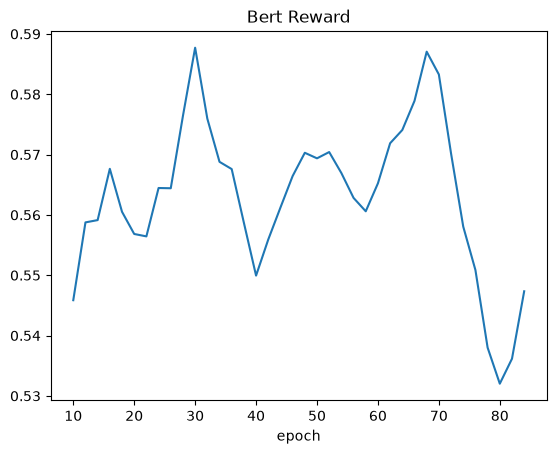

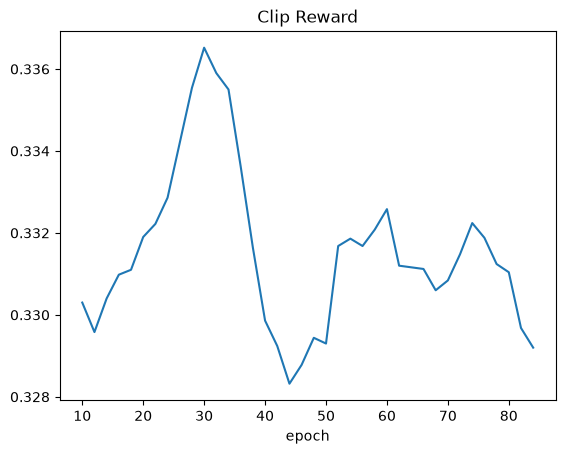

In [18]:
import matplotlib.pyplot as plt

eval_summary = eval_df.pivot_table(
    index=['method', 'score'],
    columns='epoch',
    values='value',
)
eval_summary.T.iloc[:, 0].rolling(5).mean().plot()
plt.title("Bert Reward")
plt.show()
eval_summary.T.iloc[:, 1].rolling(5).mean().plot()
plt.title("Clip Reward")
plt.show()